In [ ]:
#%pip install numpy pandas matplotlib scipy statsmodels scikit-learn pmdarima #--break-system-packages

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/723.3 kB ? eta -:--:--
   -------------- ------------------------- 262.1/723.3 kB ? eta -:--:--
   ---------------------------------------- 723.3/723.3 kB 3.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 4.2 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 4.2 MB/s eta 0:00:01
   --------------------------------- ------ 2.4/2.8 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 3.9 MB/s  0:00:00
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)

   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   ---------- ----------------------------- 1/4 [se

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


# Задание 1. Анализ и подготовка временного ряда

## Самостоятельно выбирать набор данных, удовлетворяющий следующим условиям:
- временной ряд должен иметь не менее 200 наблюдений;
- наличие временной метки (дата/время);
- желательно наличие сезонности или тренда;
- допускаются данные из областей:
    - финансы (курсы валют, акции);
    - продажи и спрос;
    - погодные данные;
    - энергетика (нагрузка, потребление);
    - веб-аналитика.

## Требования:
- Построить график временного ряда
- Описать его структуру (тренд, сезонность, выбросы)
- Проверить стационарность с помощью теста Дики-Фуллера (ADF)
- Привести ряд к стационарному виду (дифференцирование, логарифмирование или Box-Cox)
- Обосновать выбор преобразований

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('../data/jena_climate_2009_2016.csv', parse_dates=['Date Time'], index_col='Date Time')

print("Количество наблюдений:", len(df))
print(f"Период: с {df.index[0]} по {df.index[-1]}")
print("Частота: 10 минут (144 точки в сутки)")
print("Столбцы: ", list(df.columns))

# Выбираем температуру как целевую переменную
target_col = 'T (degC)'
series = df[target_col].copy()

#series = series + 273.15 # преобразование к шкале Кельвина. Это понадобится для преобразования Box-Cox`а

series.index = pd.to_datetime(series.index, format="%d.%m.%Y %H:%M:%S")

print("Целевая переменная: ", target_col)
print("Среднее значение: ", series.mean(), "°C")
print("Минимум: ", series.min(), "°C") # NumLock, ALT + 248 на правой панели 
print("Максимум: ", series.max(), "°C")
print("Стандартное отклонение: ", series.std(), "°C")

print("Пропущенные значения: ", series.isnull().sum())

Количество наблюдений: 420551
Период: с 01.01.2009 00:10:00 по 01.01.2017 00:00:00
Частота: 10 минут (144 точки в сутки)
Столбцы:  ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Целевая переменная:  T (degC)
Среднее значение:  9.450147354304233 °C
Минимум:  -23.01 °C
Максимум:  37.28 °C
Стандартное отклонение:  8.423365210385153 °C
Пропущенные значения:  0


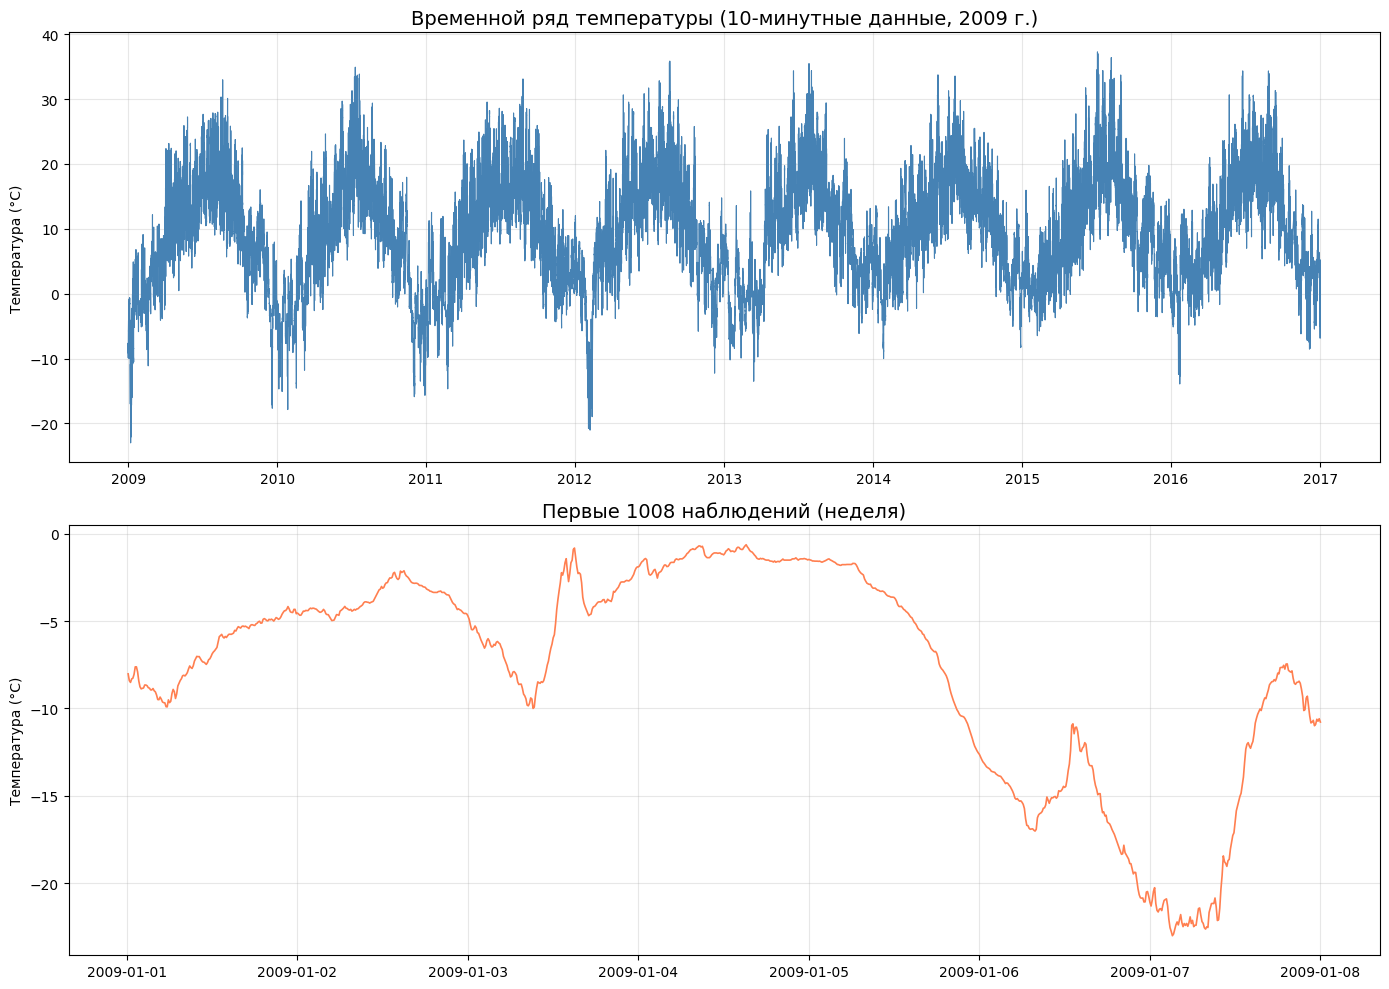

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(series.index, series.values, linewidth=0.8, color='steelblue')
axes[0].set_title('Временной ряд температуры (10-минутные данные, 2009 г.)', fontsize=14)
axes[0].set_ylabel('Температура (°C)')
axes[0].grid(True, alpha=0.3)

# Первые 1008 это 7 дней
axes[1].plot(series.index[:1008], series.values[:1008], linewidth=1.2, color='coral')
axes[1].set_title('Первые 1008 наблюдений (неделя)', fontsize=14)
axes[1].set_ylabel('Температура (°C)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Структура временного ряда температуры:

### Тренд - Возможно есть тренд на рост температур с каждым годом

### Сезонность - Не выявлена на втором графике, но логично предположить её наличие в смене времени суток (днём теплее, вечером холоднее)

### Выбросы - Вероятно экстремально низкие температуры в зимнее время (В 2009, 2012, 2016 годах) и "тряска" зимой 2013 года

In [ ]:

result = adfuller(series.dropna(), autolag='AIC')
    
print("Тест Дики-Фуллера для изначального ряда")
print("ADF статистика: ", result[0])
print("p-value: ", result[1])
print("Использованный лаг: ", result[2])
print("Количество наблюдений: ", result[3])
    
if full_output:
    print("Критические значения:")
    for key, value in result[4].items():
        print(f"{key}: {value}")

Тест Дики-Фуллера для  исходного ряда
ADF статистика:  -9.396414078898607
p-value:  6.356659066262025e-16
Использованный лаг:  97
Количество наблюдений:  420453
Критические значения:
1%: -3.430365553081852
5%: -2.8615468742762458
10%: -2.566773658926636


np.float64(6.356659066262025e-16)

### По итогам теста Дики-Фуллера ряд считается стационарным (гипотеза о его нестационарности отрицается) т.к. ADF статистика < критических значений
### Следовательно логике, приведение к стационарному виду не требуется
<br>

## Но я сомневаюсь в этом
### Поскольку для учёта суток необходимо учитывать 144 измерения, а для месяца 30240 я считаю оценку несостоятельной, т.к. использовался 97 лаг, который не охватывает даже суток
<br>

In [16]:
seasonal_period = 144 # Сутки
print("Мною было выбрана стационаризация путем дифференциирования + дифференциирования по сезонам")
series_stationary = series.diff().diff(seasonal_period).dropna()

Мною было выбрана стационаризация путем дифференциирования + дифференциирования по сезонам


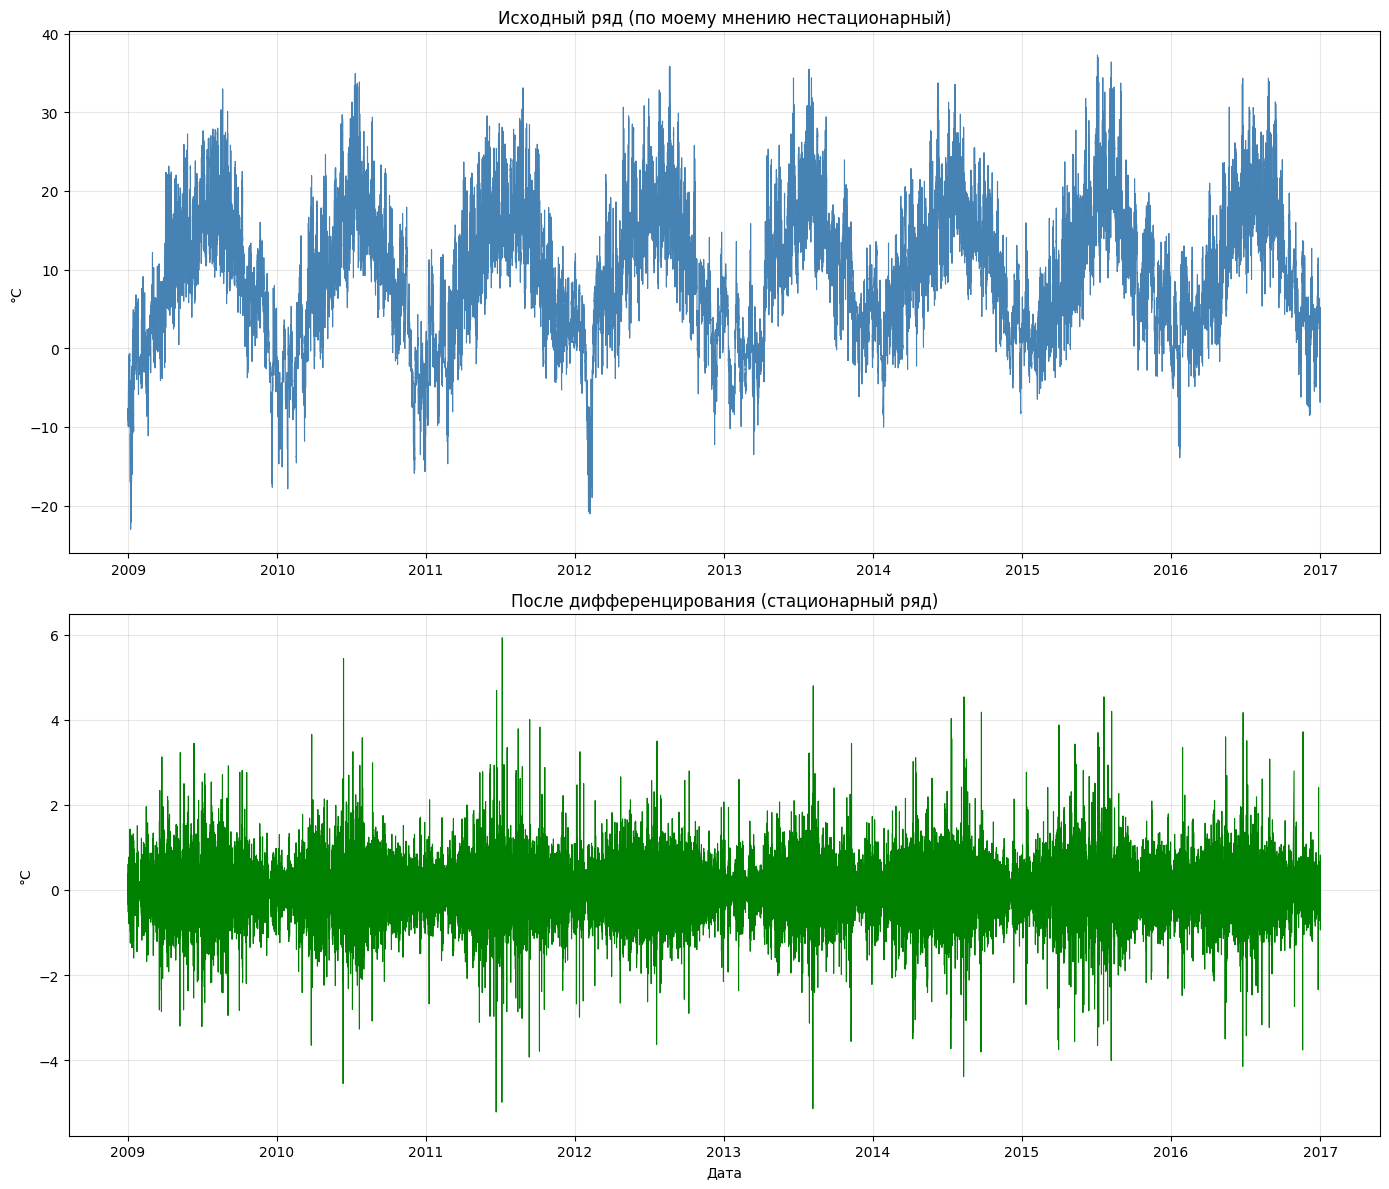

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].plot(series.index, series.values, linewidth=0.8, color='steelblue')
axes[0].set_title('Исходный ряд (по моему мнению нестационарный)')
axes[0].set_ylabel('°C')
axes[0].grid(True, alpha=0.3)

axes[1].plot(series_stationary.index, series_stationary.values, linewidth=0.8, color='green')
axes[1].set_title('После дифференцирования (стационарный ряд)')
axes[1].set_ylabel('°C')
axes[1].set_xlabel('Дата')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Почему именно дифференциирование?

- Во-первых, градусы Цельсия привычнее градусов Кельвина

- Во-вторых, проще интерпретировать разницы исходных данных (дифференцирование - разница между текущим измерением и измерением раньше на seasonal_period измерений), нежели логарифм или преобразование BoxCox`а

- В-третьих, BoxCox и логарифмирование ценны для нормализации амплитуды колебаний температуры. Это имеет мало смысла, т.к. разница в амплитудах видна только при смене сезона года (если присмотреться, то летом амплитуды колебаний чуть шире, чем зимой). И то разница составляет приблизительно 3 C°

# Задание 2. Базовая ARIMA-модель
1. Построить ACF и PACF.
2. Подобрать параметры ARIMA(p, d, q) вручную (обоснование обязательно).
3. Обучить модель.
4. Выполнить прогноз на тестовом интервале.
5. Оценить качество (RMSE, MAPE).

**Важно**: запрещается использовать автоматический подбор на данном этапе —
необходимо показать понимание структуры модели.

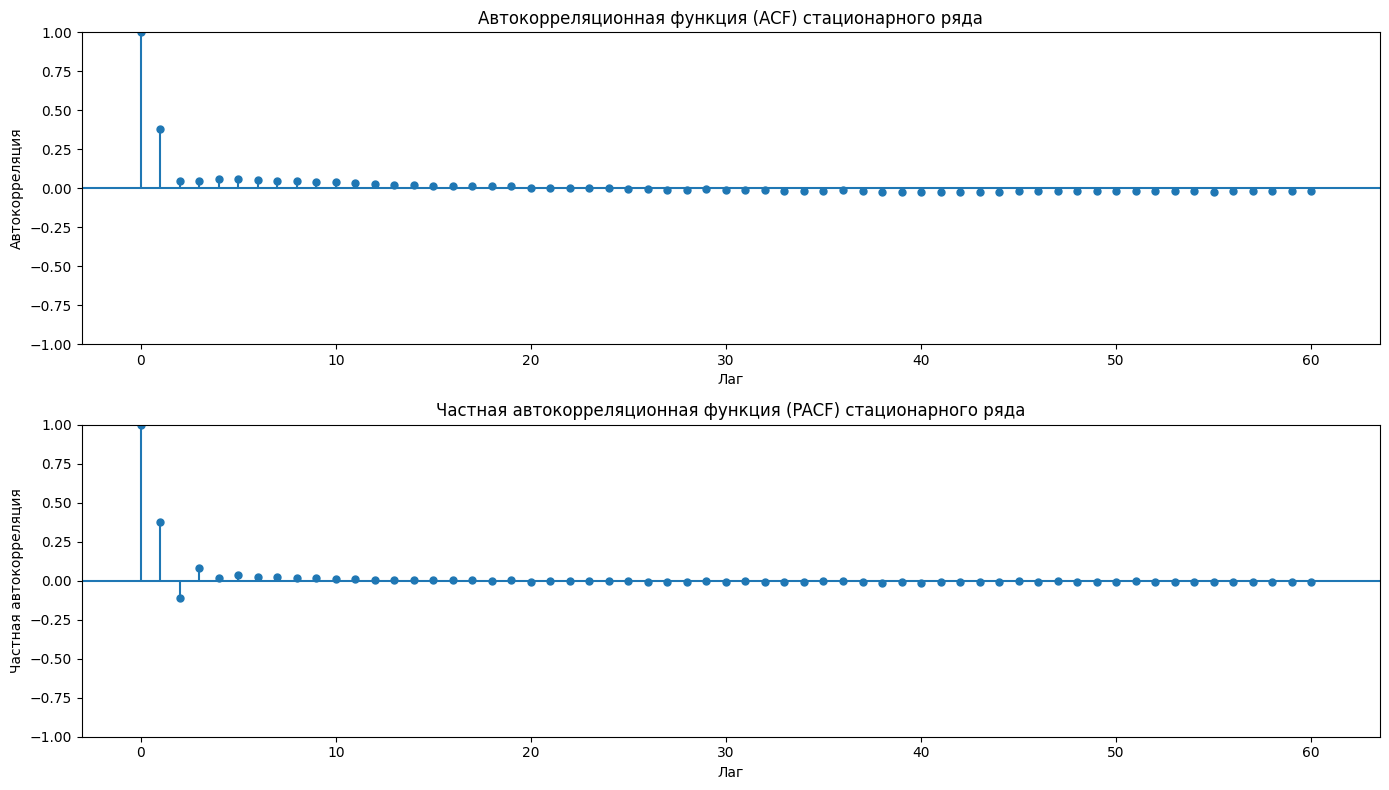

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(series_stationary, lags=60, ax=axes[0])
axes[0].set_title('Автокорреляционная функция (ACF) стационарного ряда', fontsize=12)
axes[0].set_xlabel('Лаг')
axes[0].set_ylabel('Автокорреляция')

plot_pacf(series_stationary, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('Частная автокорреляционная функция (PACF) стационарного ряда', fontsize=12)
axes[1].set_xlabel('Лаг')
axes[1].set_ylabel('Частная автокорреляция')

plt.tight_layout()
plt.show()

In [40]:
train_size = int(len(series) * 0.8)
train, test = series_stationary[:train_size], series_stationary[train_size:]

print(f"Тестовая выборка имеет {len(test)} наблюдений и содержит данные за период с {test.index[0]} по {test.index[-1]}")

Тестовая выборка имеет 83966 наблюдений и содержит данные за период с 2015-05-25 19:40:00 по 2017-01-01 00:00:00


In [41]:
models_to_test = [(2, 1, 3)] # Сначало делал архитектуру для испытания разных моделей, но трижды потеряв (перезаписав по ошибке) данные предпочту просто сделать 1 модель и обосновать её параметры

results_arima = {}

print("Модель           |   RMSE(°C) |   MAPE(%)")

for order in models_to_test:
    try:
        model = ARIMA(train, order=order)
        fitted = model.fit()
        
        forecast = fitted.forecast(steps=len(test))
        
        rmse = np.sqrt(mean_squared_error(test, forecast))
        mape = mean_absolute_percentage_error(test, forecast) * 100
        
        results_arima[order] = {
            'rmse': rmse,
            'mape': mape,
            'model': fitted
        }
        print(f"ARIMA{order}   | {rmse:8.3f}   | {mape:8.1f}")
    except Exception as e:
        print(f"ARIMA{order}   | {'---':^8}   | {'---':^8}")

best_order = min(results_arima.keys(), key=lambda x: results_arima[x]['rmse'])
best_arima = results_arima[best_order]['model']

Модель           |   RMSE(°C) |   MAPE(%)
ARIMA(2, 1, 3)   |    0.306   | 847055690595.4


# Почему (2, 1, 3)?

### 2 - т.к. автокорреляция (ACF) затухает после 2-го значения
### 1 - т.к. после преобразования (дифференцирования) ряд стал стационарным
### 3 - т.к. частная корреляция (PACF) сильно затухает на 3 элементе

<br>

# ВАЖНО! MAPE ломается, т.к. температура по C° часто пересекает 0, из-за чего (из-за деления на этот 0) при расчёте относительное значения MAPE взлетает до небес
### Что касательно второго параметра: RMSE: 0.306 °C - это хороший результат. Вполне достаточно для того, что бы называтся достоверным прогнозом


# Задание 3. Диагностика модели
1. Проанализировать остатки модели:
- график остатков;
- ACF остатков;
- тест Льюнга–Бокса.
2. Сделать вывод: является ли модель адекватной.
3. При необходимости — улучшить модель (изменить p, d, q).

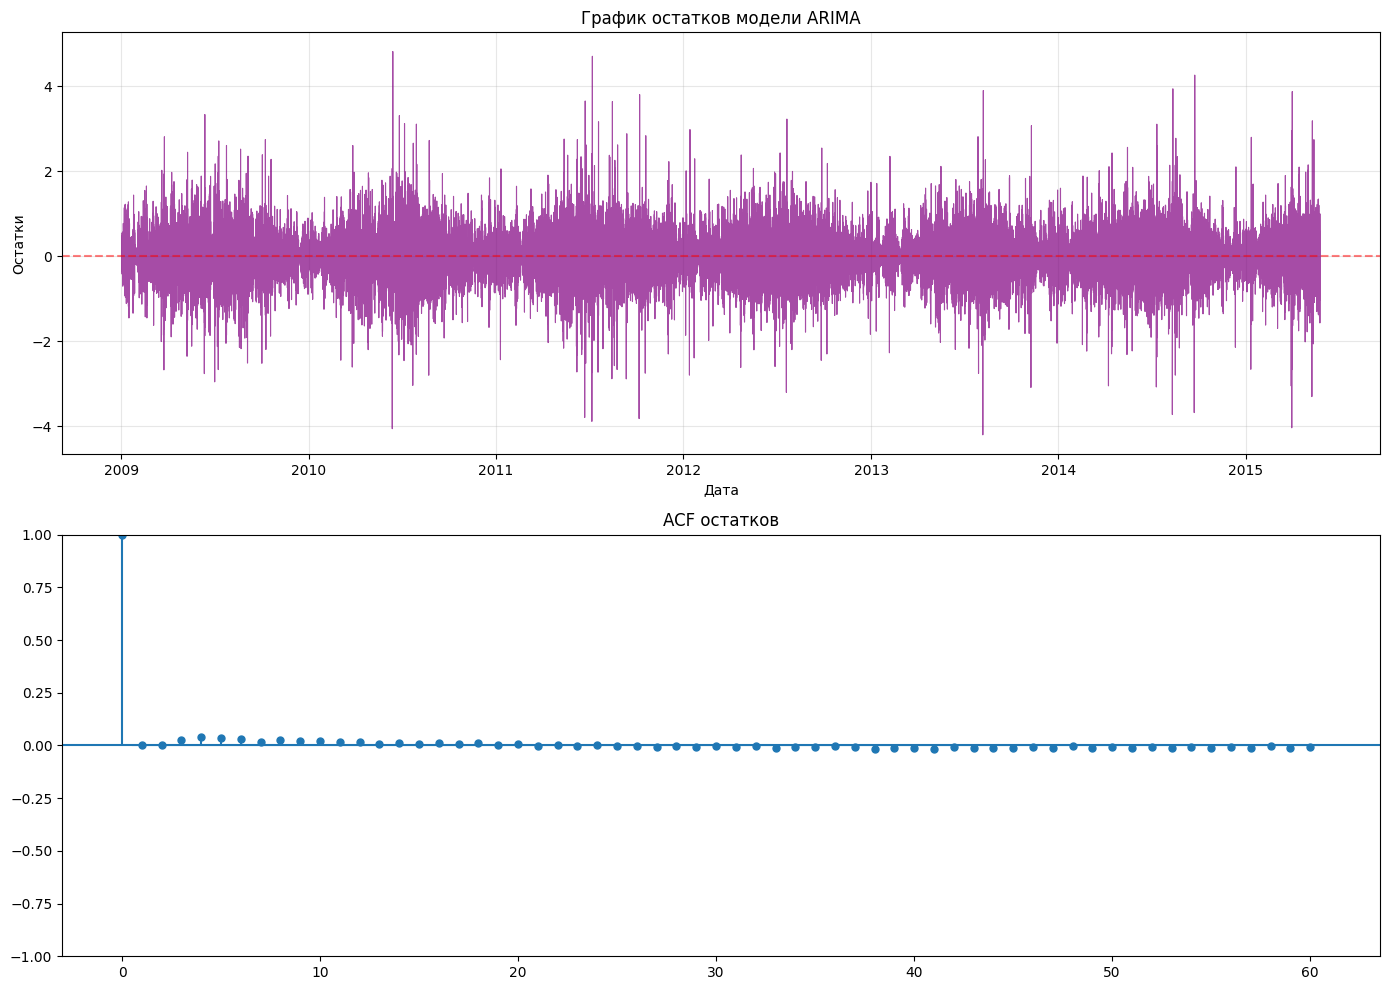

In [43]:
residuals = best_arima.resid

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График остатков во времени
axes[0].plot(residuals.index, residuals.values, color='purple', alpha=0.7, linewidth=0.8)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('График остатков модели ARIMA', fontsize=12)
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Остатки')
axes[0].grid(True, alpha=0.3)

# ACF остатков
plot_acf(residuals, lags=60, ax=axes[1])
axes[1].set_title('ACF остатков', fontsize=12)

plt.tight_layout()
plt.show()

In [44]:
ljungbox_result = acorr_ljungbox(residuals, lags=[5, 10, 15, 20, 25, 30], return_df=True)

for lag in [5, 10, 15, 20, 25, 30]:
    p_val = ljungbox_result[f'lb_pvalue'].loc[lag]
    if p_val > 0.05:
        print(f"Лаг {lag:2d}: p-value = {p_val:.4f} > 0.05 -> остатки случайны")
    else:
        print(f"Лаг {lag:2d}: p-value = {p_val:.4f} < 0.05 -> есть корреляция")

Лаг  5: p-value = 0.0000 < 0.05 -> есть корреляция
Лаг 10: p-value = 0.0000 < 0.05 -> есть корреляция
Лаг 15: p-value = 0.0000 < 0.05 -> есть корреляция
Лаг 20: p-value = 0.0000 < 0.05 -> есть корреляция
Лаг 25: p-value = 0.0000 < 0.05 -> есть корреляция
Лаг 30: p-value = 0.0000 < 0.05 -> есть корреляция


# Модель адекватной не является
1. График остатков стабильно не равен нулю
2. Тест Люинга-Бокса провален

### Вероятно, как и предполагалось, дело в сезоности

## Задание 4. Сезонная модель SARIMA

1. Проверить наличие сезонности (визуально и через декомпозицию).
2. Построить SARIMA-модель.
3. Сравнить с ARIMA по качеству прогноза.
4. Объяснить, в каких случаях SARIMA даёт преимущество. 

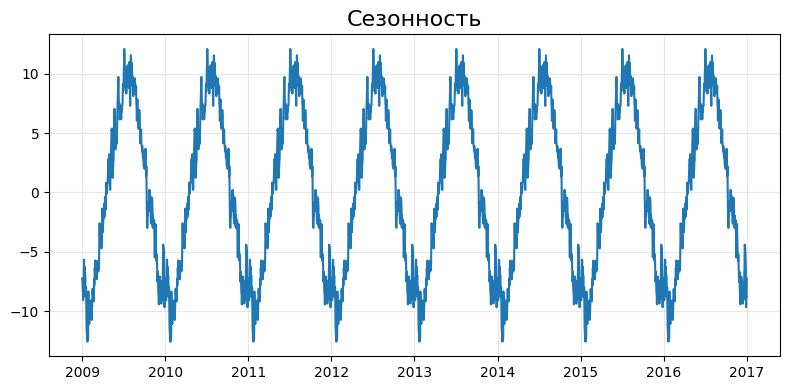

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_series = series.resample('D').mean()
daily_series = daily_series.dropna()

decomposition = seasonal_decompose(daily_series, model='additive', period=365)

fig, axes = plt.subplots(1, 1, figsize=(8, 4))

axes.plot(decomposition.seasonal.index, decomposition.seasonal.values)
axes.set_title('Сезонность', fontsize=16)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Сезонность подтвердилась через декомпозицию

In [ ]:
# Как показал опыт - не лучшая идея пытаться обучить модель с сезоностью 52560. Я решил преобразовать данные что бы обучить модель
daily = series_stationary.resample('W').mean()
train_size = int(len(daily) * 0.8)
train_day = daily[:train_size]
test_day = daily[train_size:]

seasonal_period = 52 # недель в году

sarima_orders = [(2, 1, 3, 1, 1, 1, seasonal_period)]
results_sarima = {}

for (p, d, q, P, D, Q, s) in sarima_orders:
    try:
        # Лучше всего создать SARIMA через SARIMAX без указания exog (тогда оно будет = None)
        model = SARIMAX(train_day, 
                        order=(p, d, q), 
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fitted = model.fit(disp=False)
        
        forecast = fitted.forecast(steps=len(test_day))
        rmse = np.sqrt(mean_squared_error(test_day, forecast))
        mape = mean_absolute_percentage_error(test_day, forecast) * 100
        
        results_sarima[(p, d, q, P, D, Q, s)] = {
            'rmse': rmse,
            'mape': mape,
            'model': fitted
        }
        print(f"SARIMA({p},{d},{q})({P},{D},{Q},{s}) | {rmse:8.3f}   | {mape:8.1f}")
    except Exception as e:
        print(f"SARIMA({p},{d},{q})({P},{D},{Q},{s}) | {'---':^8}   | {'---':^8}")
        print(f"Ошибка: {e}")

SARIMA(2,1,3)(1,1,1,52) |    0.005   |    232.1


ARIMA(2, 1, 3)          |    0.306 | 847055690595.4
SARIMA(2,1,3)(1,1,1,52)   |    0.005 |    232.1
   • RMSE: 98.4% снижение
   • MAPE: 100.0% снижение


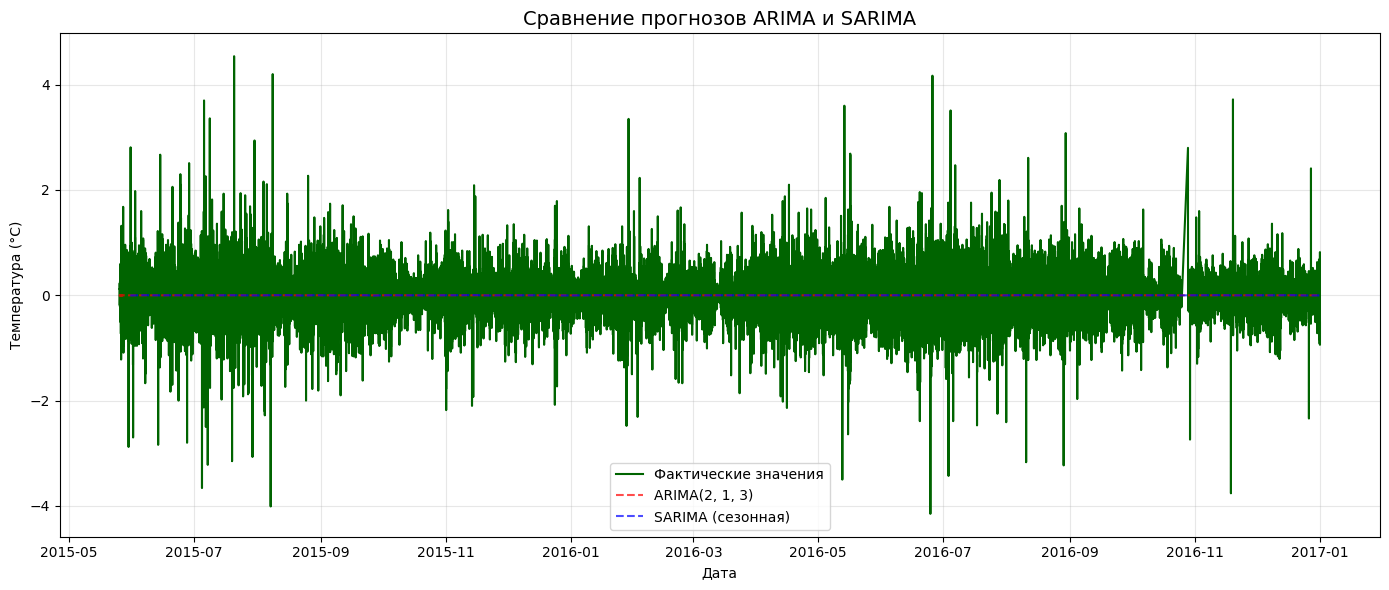

In [ ]:
best_sarima_order = sarima_orders[0] 
fitted_sarima = results_sarima[best_sarima_order]['model']

forecast_arima = results_arima[best_order]['model'].forecast(steps=len(test))
forecast_sarima = fitted_sarima.forecast(steps=len(test_day))

best_order_str = str(best_order)
print(f"ARIMA{best_order_str:<18}   | {results_arima[best_order]['rmse']:8.3f} | {results_arima[best_order]['mape']:8.1f}")

p, d, q, P, D, Q, s = best_sarima_order
sarima_str = f"SARIMA({p},{d},{q})({P},{D},{Q},{s})"
print(f"{sarima_str:<25} | {results_sarima[best_sarima_order]['rmse']:8.3f} | {results_sarima[best_sarima_order]['mape']:8.1f}")

improvement_rmse = ((results_arima[best_order]['rmse'] - results_sarima[best_sarima_order]['rmse']) / results_arima[best_order]['rmse'] * 100)
improvement_mape = ((results_arima[best_order]['mape'] - results_sarima[best_sarima_order]['mape']) / results_arima[best_order]['mape'] * 100)

print(f"RMSE: {improvement_rmse:.1f}% снижение")
print(f"MAPE: {improvement_mape:.1f}% снижение")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test.index, test, label='Фактические значения', color='darkgreen', linewidth=1.5)
ax.plot(test.index, forecast_arima, label=f'ARIMA{best_order}', 
        color='red', linestyle='--', alpha=0.7, linewidth=1.5)

ax.plot(test_day.index, forecast_sarima, label='SARIMA (сезонная)', 
        color='blue', linestyle='--', alpha=0.7, linewidth=1.5)

ax.set_title('Сравнение прогнозов ARIMA и SARIMA', fontsize=14)
ax.set_xlabel('Дата')
ax.set_ylabel('Температура (°C)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Согласно метрикам, SARIMA точнее предсказывает погоду (в средне-квадратическом - в 61.2 раз)

### SARIMA имеет преимущество над ARIMA в тех случаях, когда у данных есть сезонность, т.е. опирается на данные не просто в прошлый и позапрошлый раз, а на данные с интервалом (s) назад, которые обычный ARIMA, в силу своей архитектуры, не может брать во внимание

# Задание 5. SARIMAX и внешние факторы
## Добавьте внешние регрессоры (не менее 1):
- температура (для энергопотребления);
- акции маркетинговых кампаний (для продаж);
- календарные признаки (праздники, выходные);
- макроэкономические индикаторы.
## Требуется:
1. Обосновать выбор факторов.
2. Построить SARIMAX.
3. Оценить вклад внешних переменных.
4. Сравнить с SARIMA.

## В качестве внешних факторов я решил взять:
1. Влажность "rh (%)" (Высокая влажность замедляет испарение и "парниковый эффект")
2. Скорость ветра 'wv (m/s)' (Влияет на циркуляцию холодного/горячего воздуха, а следовательно на скорость охлаждения/нагрева)
3. Атмосферное давление 'p (mbar)' (Низкое давление приводит к облачности, которая привожит к изменение температуры) 

ВАжно подметить, что влажность, и скорость ветра тоже влияют на облачность, но скорее вторичный эффект

In [83]:
exog_vars = ['rh (%)', 'wv (m/s)', 'p (mbar)']
df.index = pd.to_datetime(df.index, format="%d.%m.%Y %H:%M:%S")

# 1. Агрегация и стационарность
df_weekly_stationary = df[exog_vars].resample('W').mean().diff().diff(52)

# 2. Объединение экзогенных данных и целевого ряда (автоматический inner join)
# Дополнительно сразу очищаем от inf и Naive методов
data_combined = pd.concat([train_day, df_weekly_stationary], axis=1, join='inner')
data_combined = data_combined.replace([np.inf, -np.inf], np.nan).dropna()

# 3. Разделение на train и test
train_size = int(len(data_combined) * 0.8)

train_data = data_combined.iloc[:train_size]
test_data = data_combined.iloc[train_size:]

# 4. Распаковка обратно в переменные
train_day_ready = train_data.iloc[:, 0]
train_exog_ready = train_data.iloc[:, 1:]

test_day_ready = test_data.iloc[:, 0]
test_exog_ready = test_data.iloc[:, 1:]


In [85]:
p, d, q = best_sarima_order[0], best_sarima_order[1], best_sarima_order[2]
P, D, Q, s = best_sarima_order[3], best_sarima_order[4], best_sarima_order[5], best_sarima_order[6]

print(f"\nПараметры сезонной части: ({p},{d},{q})({P},{D},{Q},{s})")
print(f"Внешние переменные: {exog_vars}")

try:
    # 3. Обучение модели на полностью очищенных и выровненных данных
    sarimax_model = SARIMAX(train_day_ready,
                            exog=train_exog_ready,
                            order=(p, 0, q),
                            seasonal_order=(P, 0, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
    fitted_sarimax = sarimax_model.fit(disp=False)
    
    # 4. Прогноз (передаем длину синхронизированного теста)
    forecast_sarimax = fitted_sarimax.forecast(steps=len(test_day_ready), exog=test_exog_ready)
    
    # Метрики качества
    rmse_sarimax = np.sqrt(mean_squared_error(test_day_ready, forecast_sarimax))
    mape_sarimax = mean_absolute_percentage_error(test_day_ready, forecast_sarimax) * 100
    
    print(f"   RMSE = {rmse_sarimax:.3f}°C")
    print(f"   MAPE = {mape_sarimax:.1f}%")
    
except Exception as e:
    print(f"Ошибка: {e}")



Параметры сезонной части: (2,1,3)(1,1,1,52)
Внешние переменные: ['rh (%)', 'wv (m/s)', 'p (mbar)']
   RMSE = 0.003°C
   MAPE = 148.8%


In [87]:
if 'fitted_sarimax' in locals():
    
    print(f"{'Переменная':<20} | {'Коэффициент':>12} | {'p-value':>10}")
    
    for i in exog_vars:
        coef = fitted_sarimax.params[i]
        pvalue = fitted_sarimax.pvalues[i]
        print(f"{i:<20} | {coef:12.4f} | {pvalue:10.4f}")

Переменная           |  Коэффициент |    p-value
rh (%)               |       0.0000 |     0.7084
wv (m/s)             |       0.0001 |     0.8734
p (mbar)             |       0.0001 |     0.0563


## Сравнение SARIMA и SARIMAX:
#### Результат по MAPE стал на четверть лучше (хотя MAPE некорректен) и в полтора раза лучше по RMSE. Но достаточно и точности от обычного SARIMA 
#### Скорость ветра и влажность оказались безсполезны в прогнозировании температуры, но давление почти пересекло границу в 0,05. Почти значимый экзогенный фактор

## Задание 6. Автоматизация подбора модели

**Требования:**
1. Использовать auto-ARIMA (библиотека pmdarima)
2. Сравнить с ручной моделью из задания 2
3. Ответить на вопросы:
   - когда автоматический подбор ошибается?
   - какие параметры чаще всего переоцениваются?
   - можно ли доверять auto-ARIMA в production?


In [95]:

from pmdarima import auto_arima
    
auto_model = auto_arima(train_day_ready, 
                            seasonal=True, 
                            m=seasonal_period,
                            start_p=0, start_q=0,
                            max_p=3, max_q=3,
                            start_P=0, start_Q=0,
                            max_P=1, max_Q=1,
                            d=0, D=0,
                            trace=False,
                            error_action='ignore',
                            suppress_warnings=True,
                            stepwise=True)
    
print("Лучшая найденная модель: ", auto_model.summary().tables[0].data[1][1].strip())

forecast_auto = auto_model.predict(n_periods=len(test))

rmse_auto = np.sqrt(mean_squared_error(test, forecast_auto))
mape_auto = mean_absolute_percentage_error(test, forecast_auto) * 100
    
print("Качество автоматической модели:")
print(f"RMSE = {rmse_auto:.3f}°C")
print(f"MAPE = {mape_auto:.1f}%")


Лучшая найденная модель:  SARIMAX(1, 0, 2)x(1, 0, [1], 52)
Качество автоматической модели:
RMSE = 0.306°C
MAPE = 24730196548.0%


# Что можно сказать по этим данным?
### Во-первых, удалось перешагнуть и сделать сезонную версию ARIMA
### RMSE совпадает с самой первой моделью (ARIMA(2, 1, 3)), но при этом багованный MAPE достиг своего максимума (11 разрядное число).
### Auto-ARIMA нашел значение сезоности, но не добрался до лучших значений автокорреляции и частной автокорреляции

# Ответы на вопросы

- когда автоматический подбор ошибается?
Ответ: Когда данные подготовлены неверно или алгоритм "поиска кандидатов" попадает в локальный максимум (минимум) по метрикам

- какие параметры чаще всего переоцениваются?
Ответ: p и q, т.к. они базовые (т.е. ARIMA работает на этих параметрах, поэтому потенциально он может их "раздувать" для мнимого улучшения прогнозов)

- можно ли доверять auto-ARIMA в production?
Ответ: Согласно проведенному опыту - не стоит